In [28]:
import numpy as np
import matplotlib.pyplot as plt

from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross

rng = np.random.default_rng()

In [29]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k]/(self.Ny-1) - 0.5) * self.var)
    return c

In [30]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 8 # number of parameters for diffusion coeff
n_param = n_a_param 
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters

cfun = diffusion_coeff(Nx, Ny, offset, var)

tol = 1e-3

param_shape = tuple([Ny] * n_param)

# tree = Tree.from_tupletree((0,(1,((2,3), ((4,5),(6,7))))))
tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,(6,(7,8)))))))))
# tree = Tree.from_tupletree((0,(1,2)))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=25, eps=1e-9, kickrank=25, verbose=True)
C_a.print()
C_a.round(tol=tol)
# cross.run(cfun, n_iter=10, eps=0, kickrank=1, verbose=True, force_init=True)
# C_a._orth_subtree_maxvol(C_a.tree.root)
# C_a.round(tol=tol)
C_a.print()


[16] (root) 
 + [0] (dim 0)
 + [15] 
    + [1] (dim 1)
    + [14] 
       + [2] (dim 2)
       + [13] 
          + [3] (dim 3)
          + [12] 
             + [4] (dim 4)
             + [11] 
                + [5] (dim 5)
                + [10] 
                   + [6] (dim 6)
                   + [9] 
                      + [7] (dim 7)
                      + [8] (dim 8)

swp:  1/25 f_evals=1700
swp:  2/25 f_evals=8100
swp:  3/25 f_evals=15100
swp:  4/25 f_evals=22100
swp:  5/25 f_evals=29100
swp:  6/25 f_evals=36100
swp:  7/25 f_evals=43100
swp:  8/25 f_evals=50100
swp:  9/25 f_evals=57100
swp: 10/25 f_evals=64100
swp: 11/25 f_evals=71100
swp: 12/25 f_evals=78100
swp: 13/25 f_evals=85100
swp: 14/25 f_evals=92100
swp: 15/25 f_evals=99100
swp: 16/25 f_evals=106100
swp: 17/25 f_evals=113100
swp: 18/25 f_evals=120100
swp: 19/25 f_evals=127100
swp: 20/25 f_evals=134100
swp: 21/25 f_evals=141100
swp: 22/25 f_evals=148100
swp: 23/25 f_evals=155100
swp: 24/25 f_evals=162100
swp: 25/25 f_e

RMS l2 err = 1.06e-02


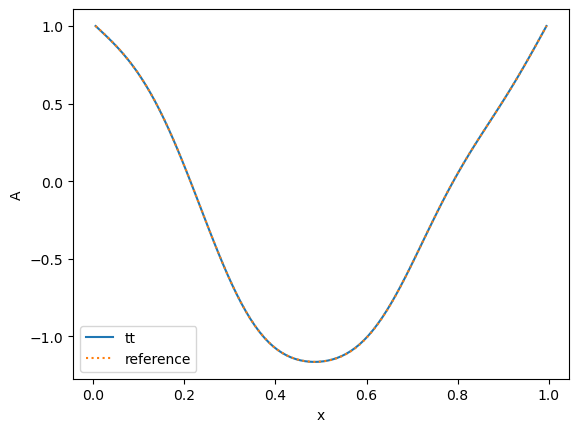

In [31]:
N_MC = 500
errs = np.zeros(N_MC)

for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = np.linalg.norm(C_eval-C_true)

print(f'RMS l2 err = {np.sqrt(np.mean(np.square(errs))):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [32]:
runs = 10

errs_linear = []
evals_linear = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,(6,(7,8)))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=25, verbose=False)
  C_a.round(tol=tol)

  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(C_a[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = np.linalg.norm(C_eval-C_true)

  errs_linear += [np.sqrt(np.mean(np.square(errs)))]
  evals_linear += [cross.n_eval]

In [33]:
errs_fancy = []
evals_fancy = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,((2,(3,4), (5,(6,(7,8))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=25, verbose=False)
  C_a.round(tol=tol)

  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(C_a[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = np.linalg.norm(C_eval-C_true)

  errs_fancy += [np.sqrt(np.mean(np.square(errs)))]
  evals_fancy += [cross.n_eval]

In [34]:
errs_balanced = []
evals_balanced = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(((1,2),(3,4)),((5,6),(7,8)))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=25, verbose=False)
  C_a.round(tol=tol)

  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(C_a[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = np.linalg.norm(C_eval-C_true)

  errs_balanced += [np.sqrt(np.mean(np.square(errs)))]
  evals_balanced += [cross.n_eval]

In [35]:
print(np.mean(evals_linear))
print(np.mean(evals_fancy))
print(np.mean(evals_balanced))

168930.0
168038.5
168490.0


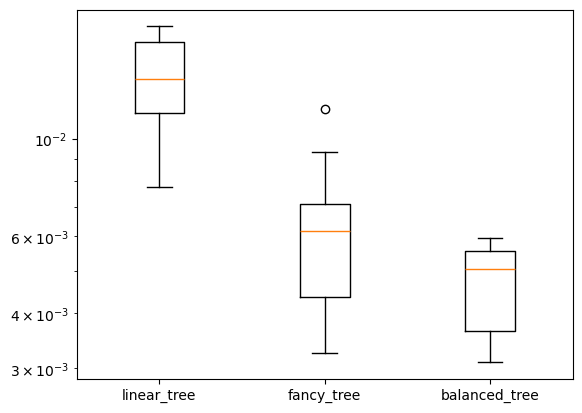

In [36]:
fig, ax = plt.subplots()

ax.boxplot([errs_linear,errs_fancy, errs_balanced], tick_labels=['linear_tree', 'fancy_tree', 'balanced_tree'])
ax.set_yscale('log')